# Базовые модели

Baseline без feature engineering, полиномиальная регрессия, PCA + линейная регрессия, логистическая классификация.

In [14]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.preprocessing import (
    load_raw_data, filter_region, create_binary_target,
    get_Xy, split_data, scale_features,
    FEATURES, TARGET_REG, TARGET_CLF,
)
from src.modeling import (
    train_polynomial_regression, pca_regression, train_logistic_regression,
)

plt.rcParams["figure.dpi"] = 110

In [15]:
raw = load_raw_data("../data/raw/Доходы домохозяйств_2023.xlsx")
df = filter_region(raw)
df, q3 = create_binary_target(df)
print(f"Домохозяйств: {len(df)}, Q3: {q3:,.0f} руб.")

X_clf, y_clf = get_Xy(df, FEATURES, TARGET_CLF)
X_tr, X_te, y_tr, y_te = split_data(X_clf, y_clf, stratify=y_clf)

X_reg, y_reg = get_Xy(df, FEATURES, TARGET_REG)
X_tr_r, X_te_r, y_tr_r, y_te_r = split_data(X_reg, y_reg)

Домохозяйств: 3803, Q3: 151,407 руб.


## Baseline: простые модели без feature engineering

Обучаем на всех 5 признаках «из коробки» — без отбора, без инженерии. Это точка отсчёта для всех последующих экспериментов.

In [16]:
# Масштабирование для KNN и логрег
X_tr_s, X_te_s, _ = scale_features(X_tr.values, X_te.values)

baselines = {}

# Линейная регрессия (для регрессионной задачи)
lr = LinearRegression().fit(X_tr_r, y_tr_r)
from sklearn.metrics import r2_score, mean_absolute_error
baselines["LinearRegression"] = {
    "task": "regression",
    "R² test": r2_score(y_te_r, lr.predict(X_te_r)),
    "MAE test": mean_absolute_error(y_te_r, lr.predict(X_te_r)),
}

# Логистическая регрессия без RFE
log = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr.values)
baselines["LogisticRegression"] = {
    "task": "classification",
    "Accuracy test": accuracy_score(y_te.values, log.predict(X_te_s)),
    "ROC-AUC test": roc_auc_score(y_te.values, log.predict_proba(X_te_s)[:, 1]),
}

# KNN
knn = KNeighborsClassifier(n_neighbors=5).fit(X_tr_s, y_tr.values)
baselines["KNN (k=5)"] = {
    "task": "classification",
    "Accuracy test": accuracy_score(y_te.values, knn.predict(X_te_s)),
    "ROC-AUC test": roc_auc_score(y_te.values, knn.predict_proba(X_te_s)[:, 1]),
}

print("=== Baseline: регрессия ===")
print(f"LinearRegression — R²={baselines['LinearRegression']['R² test']:.3f}, MAE={baselines['LinearRegression']['MAE test']:,.0f}")

print("\n=== Baseline: классификация ===")
for name in ["LogisticRegression", "KNN (k=5)"]:
    b = baselines[name]
    print(f"{name:25} — Accuracy={b['Accuracy test']:.4f}, ROC-AUC={b['ROC-AUC test']:.4f}")

=== Baseline: регрессия ===
LinearRegression — R²=0.755, MAE=25,704

=== Baseline: классификация ===
LogisticRegression        — Accuracy=0.9343, ROC-AUC=0.9844
KNN (k=5)                 — Accuracy=0.9702, ROC-AUC=0.9911


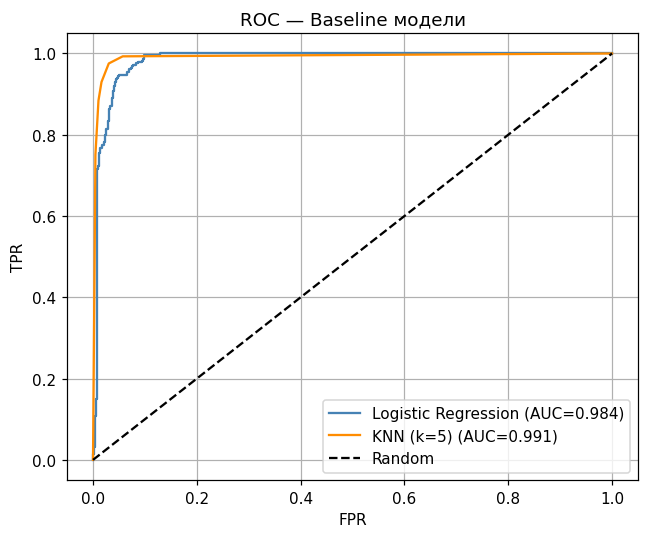

In [17]:
# ROC baseline-классификаторов
fig, ax = plt.subplots(figsize=(6, 5))

for model, label, color in [
    (log, "Logistic Regression", "steelblue"),
    (knn, "KNN (k=5)", "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_te.values, model.predict_proba(X_te_s)[:, 1])
    auc = roc_auc_score(y_te.values, model.predict_proba(X_te_s)[:, 1])
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC — Baseline модели")
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig("../report/images/baseline_roc.png", bbox_inches="tight")
plt.show()

Logistic Regression: Accuracy=0.934, ROC-AUC=0.984. KNN (k=5): Accuracy=0.970, ROC-AUC=0.991 — KNN незначительно превосходит LogReg. Оба baseline уже сильные благодаря высокой предсказательной силе признаков `rasress` и `rasq`.

## Полиномиальная регрессия

Анализируем влияние степени полинома на переобучение.

In [18]:
results = train_polynomial_regression(
    X_tr_r.values, X_te_r.values, y_tr_r.values, y_te_r.values,
    degrees=range(1, 9)
)
results

,degree,n_features,train_r2,test_r2,train_std,test_std
0,1,6,0.533746,0.755282,96166.254819,3.622997e+04
1,2,21,0.892700,0.801127,46133.071676,3.264980e+04
2,3,56,0.943339,0.477061,33523.973523,5.289816e+04
3,4,126,0.949745,-82.104226,31571.867595,6.673316e+05
4,5,252,0.861916,-918.796491,52333.850492,2.220148e+06
5,6,462,0.806890,-86.484215,61889.057249,6.848074e+05
6,7,792,0.791850,-115.645679,64253.917201,7.905197e+05
7,8,1287,0.775273,-50.659180,66763.529360,5.262698e+05


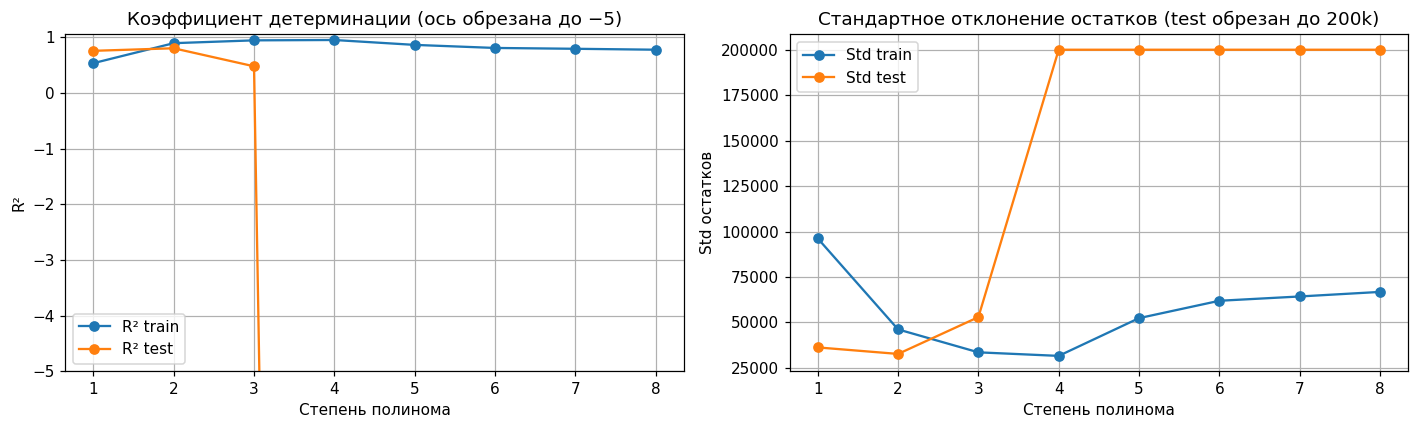

Оптимальная степень: 2, R² test=0.801


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(results["degree"], results["train_r2"], marker="o", label="R² train")
axes[0].plot(results["degree"], results["test_r2"], marker="o", label="R² test")
axes[0].set_xlabel("Степень полинома"); axes[0].set_ylabel("R²")
axes[0].set_ylim(-5, 1.05)
axes[0].set_title("Коэффициент детерминации (ось обрезана до −5)")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(results["degree"], results["train_std"], marker="o", label="Std train")
axes[1].plot(results["degree"], results["test_std"].clip(upper=200_000), marker="o", label="Std test")
axes[1].set_xlabel("Степень полинома"); axes[1].set_ylabel("Std остатков")
axes[1].set_title("Стандартное отклонение остатков (test обрезан до 200k)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("../report/images/polynomial_regression.png", bbox_inches="tight")
plt.show()

best = results.loc[results["test_r2"].idxmax()]
print(f"Оптимальная степень: {int(best['degree'])}, R² test={best['test_r2']:.3f}")

Оптимальная степень — **2** (R² test = 0.80). Степени ≥ 3 переобучаются.

## PCA + линейная регрессия

In [20]:
exclude = ["per", "ter", "mest", "bud", "doxodn", "doxodn_high"]
pca_features = [
    col for col in df.columns
    if col not in exclude and pd.api.types.is_numeric_dtype(df[col])
]
df_pca = df[pca_features + ["doxodn_high"]].dropna()
X_pca_raw = df_pca[pca_features].values
X_scaled = StandardScaler().fit_transform(X_pca_raw)
y_pca = df[TARGET_REG].loc[df_pca.index].values
y_pca_clf = df_pca["doxodn_high"].values
print(f"Признаков для PCA: {len(pca_features)}")

Признаков для PCA: 37


Компонент для >70% дисперсии: 9


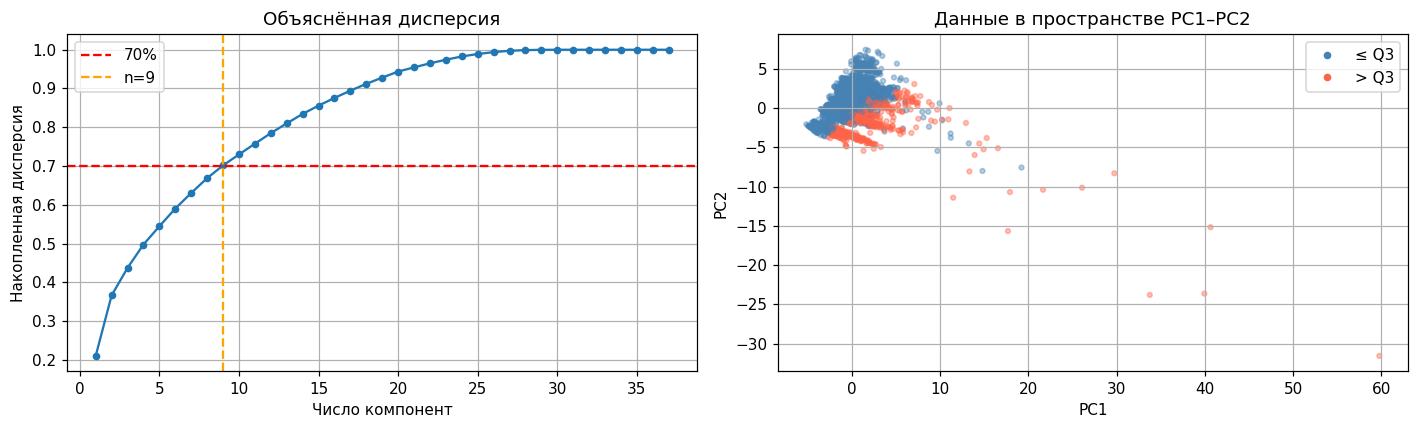

In [21]:
pca_full = PCA()
X_pca_all = pca_full.fit_transform(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)
n_components_70 = int(np.argmax(explained >= 0.7) + 1)
print(f"Компонент для >70% дисперсии: {n_components_70}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# График объяснённой дисперсии
axes[0].plot(range(1, len(explained) + 1), explained, marker="o", markersize=4)
axes[0].axhline(0.7, color="red", linestyle="--", label="70%")
axes[0].axvline(n_components_70, color="orange", linestyle="--", label=f"n={n_components_70}")
axes[0].set_xlabel("Число компонент")
axes[0].set_ylabel("Накопленная дисперсия")
axes[0].set_title("Объяснённая дисперсия")
axes[0].legend(); axes[0].grid(True)

# Scatter plot PC1 vs PC2, окраска по классу
colors = ["steelblue" if c == 0 else "tomato" for c in y_pca_clf]
axes[1].scatter(X_pca_all[:, 0], X_pca_all[:, 1], c=colors, alpha=0.4, s=10)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue", label="≤ Q3"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="tomato", label="> Q3"),
]
axes[1].legend(handles=legend_elements)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Данные в пространстве PC1–PC2")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../report/images/pca_variance.png", bbox_inches="tight")
plt.show()

In [22]:
for i, comp in enumerate(pca_full.components_[:n_components_70], 1):
    top5 = sorted(zip(pca_features, comp), key=lambda x: -abs(x[1]))[:5]
    print(f"PC{i}: " + ", ".join(f"{k}={v:.2f}" for k, v in top5))

PC1: rasress=0.31, denras=0.31, potras=0.30, rassq=0.30, doxodsn=0.26
PC2: chlicn=0.36, chlico=0.35, chisl=0.35, chdet=0.32, rasq=-0.27
PC3: prompot=0.43, fakt=-0.37, rsber=0.34, decilrfed=-0.28, nalog=-0.25
PC4: neprod=0.37, doxodsn=-0.36, drras=-0.33, fakt=-0.29, pitres=-0.28
PC5: dhsinv=0.52, dhinv=0.43, dhsdinv=0.31, drras=0.26, pitres=0.25
PC6: nps=0.55, chrab=-0.35, tips=0.34, chisd=-0.30, dhsinv=-0.25
PC7: drras=0.49, pitres=0.42, ssber=-0.31, dhsinv=-0.27, dhinv=-0.26
PC8: msem=0.45, naldet23=-0.45, naldet3=0.40, nps=-0.36, mngd=0.35
PC9: ssber=0.50, kvzv=0.41, alk=-0.33, natdox=0.32, prod=-0.29


In [23]:
pca_result = pca_regression(X_scaled, y_pca, variance_threshold=0.70, train_size=0.6)
print(f"Компонент: {pca_result['n_components']}")
print(f"R² train={pca_result['train_r2']:.3f}, test={pca_result['test_r2']:.3f}")
print(f"RMSE train={pca_result['train_rmse']:,.0f}, test={pca_result['test_rmse']:,.0f}")

Компонент: 9
R² train=0.917, test=0.750
RMSE train=43,050, test=36,764


9 главных компонент объясняют >70% дисперсии. На scatter plot PC1–PC2 видна частичная разделимость классов вдоль PC1 (экономические ресурсы).

## Логистическая регрессия с RFE

Автоматический отбор 3 наиболее значимых признаков.

In [24]:
lr_result = train_logistic_regression(X_tr, X_te, y_tr.values, y_te.values)

print(f"Признаки (RFE): {lr_result['selected_features']}")
print(f"Accuracy  train={lr_result['train_accuracy']:.4f}, test={lr_result['test_accuracy']:.4f}")
print(f"ROC-AUC   train={lr_result['train_roc_auc']:.4f}, test={lr_result['test_roc_auc']:.4f}")
print("\nКоэффициенты:")
print(lr_result["coef"])

Признаки (RFE): ['chlico', 'chdet', 'rasress']
Accuracy  train=0.9658, test=0.9606
ROC-AUC   train=0.9900, test=0.9877

Коэффициенты:
chlico    -4.381311
chdet     -0.072776
rasress    0.000026
dtype: float64


In [25]:
print("Confusion matrix (test):")
print(lr_result["test_cm"])
print("\nClassification report (test):")
print(lr_result["test_report"])

Confusion matrix (test):
[[848   8]
 [ 37 248]]

Classification report (test):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       856
           1       0.97      0.87      0.92       285

    accuracy                           0.96      1141
   macro avg       0.96      0.93      0.95      1141
weighted avg       0.96      0.96      0.96      1141



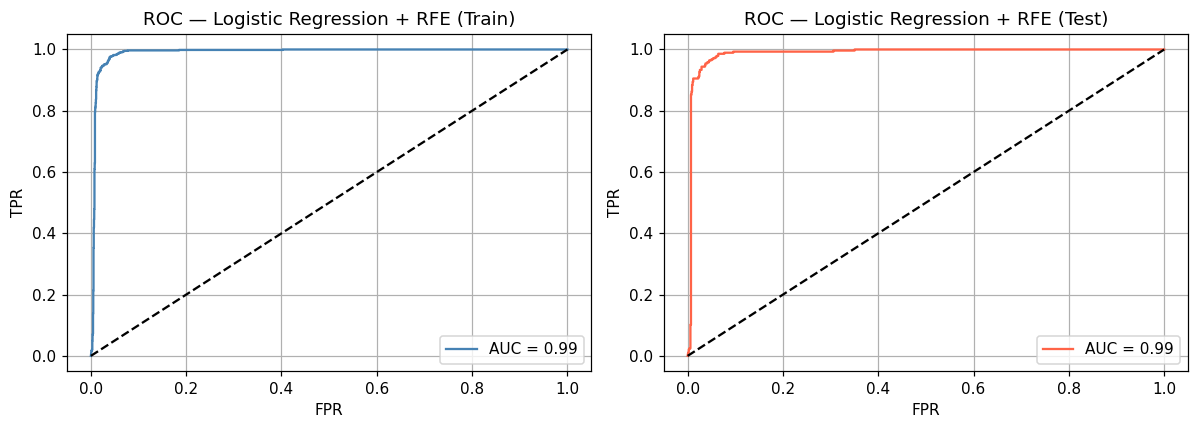

In [26]:
model = lr_result["model"]
sel = lr_result["selected_features"]
y_tr_prob = model.predict_proba(X_tr[sel])[:, 1]
y_te_prob = model.predict_proba(X_te[sel])[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_true, y_prob, split, color in zip(
    axes, [y_tr.values, y_te.values], [y_tr_prob, y_te_prob],
    ["Train", "Test"], ["steelblue", "tomato"],
):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, label=f"AUC = {lr_result[f'{split.lower()}_roc_auc']:.2f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC — Logistic Regression + RFE ({split})")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("../report/images/logistic_roc.png", bbox_inches="tight")
plt.show()

RFE отобрал `chlico`, `chdet`, `rasress`. ROC-AUC = 0.988 vs baseline 0.984 — прирост ~0.3pp. Accuracy выросла с 0.934 до 0.961: удаление `rasq` и `potras` убрало шум — для логистической регрессии эти признаки избыточны.